<a href="https://colab.research.google.com/github/madhavabrightly/facee/blob/main/100Epoch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from ultralytics import YOLO

# Load YOLOv8 Nano (or change to yolov8s.pt, yolov8m.pt, etc.)
model = YOLO('yolov8n.pt')

# Start training
results = model.train(data='/content/acne-yolo-13/data.yaml',
                      epochs=4, imgsz=640, batch=16)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (AMD EPYC 7B13)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne-yolo-13/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=4, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

In [10]:
# 1. Load the trained model
# The trained model is saved in the 'runs/detect/trainX' directory.
# You might need to adjust 'trainX' to the actual run name (e.g., 'train', 'train2', 'train3', etc.)
# Look for the last.pt file in the relevant run directory.
# For example, if your training run was named 'train', the path might be '/content/runs/detect/train/weights/best.pt'
# From the output of cell N-IXKOGPjSez, the save directory is '/content/runs/detect/train6'.
model_path = '/content/runs/detect/train6/weights/best.pt'
model = YOLO(model_path)

In [11]:
# 2. Upload a custom image for testing
from google.colab import files
import os

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))
  custom_image_path = os.path.join('/content/', fn)
  print(f"Image uploaded to: {custom_image_path}")

Saving acne-face-2__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd_jpg.rf.28b98940f22e2ee98c90351c272959d7.jpg to acne-face-2__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd_jpg.rf.28b98940f22e2ee98c90351c272959d7.jpg
User uploaded file "acne-face-2__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd_jpg.rf.28b98940f22e2ee98c90351c272959d7.jpg" with length 10572 bytes
Image uploaded to: /content/acne-face-2__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd_jpg.rf.28b98940f22e2ee98c90351c272959d7.jpg


### 1. Download the Trained Model

Your trained model is saved as a `.pt` file (PyTorch model) in the run directory. Based on your training output, it was saved in `/content/runs/detect/train6/weights/best.pt`. You'll need to download this file to your local computer.

YouYou can do this by navigating to the file in the Colab file browser (the folder icon on the left sidebar), then right-clicking on `best.pt` and selecting 'Download'.

### 2. Use the Model in VS Code (Python Script)

Once you have `best.pt` on your local machine (e.g., in the same directory as your Python script), you can use it in a Python script within VS Code. Make sure you have `ultralytics` installed in your local Python environment (`pip install ultralytics`).

Here's an example Python script (`predict_image.py`) you can use:

In [14]:
# predict_image.py

from ultralytics import YOLO
import cv2

# Path to your downloaded best.pt model file
model_path = 'best.pt' # Make sure this path is correct on your local machine

# Load the custom trained model
model = YOLO(model_path)

# Path to your custom image for testing (replace with your local image path)
image_path = 'your_custom_image.jpg'

# Perform inference on the image
# You can adjust 'conf' (confidence threshold) and 'iou' (IoU threshold) as needed
results = model.predict(source=image_path, conf=0.25, iou=0.7, save=True, show=False)

# The 'save=True' argument will save the predicted image with bounding boxes
# to a 'runs/detect/predictX' folder relative to where you run the script.
# You can then open this image to view the predictions.

print(f"Predictions saved to: {results[0].save_dir}")

# Optionally, if you want to display the image directly (requires a GUI, like with OpenCV)
# for r in results:
#     im_array = r.plot()  # plot a BGR numpy array of predictions
#     im = Image.fromarray(im_array[..., ::-1])  # RGB PIL image
#     im.show()  # show image


FileNotFoundError: [Errno 2] No such file or directory: 'best.pt'

Displaying predicted image from: /content/runs/detect/predict/acne-face-2__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd_jpg.rf.28b98940f22e2ee98c90351c272959d7.jpg


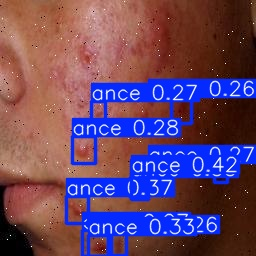

In [13]:
import glob
from IPython.display import Image

# Find the last created run directory
predict_dir = sorted(glob.glob('/content/runs/detect/predict*'))[-1]

# Find the predicted image within that directory
predicted_image_path = glob.glob(f'{predict_dir}/*.jpg')[0] # Assuming it's a JPG, adjust if needed

# Display the image
print(f"Displaying predicted image from: {predicted_image_path}")
Image(filename=predicted_image_path)

In [12]:
# 3. Perform inference on the custom image
# The 'show=True' argument will display the results directly in Colab
# The 'save=True' argument will save the predicted image to a 'runs/detect/predictX' folder
results = model.predict(source=custom_image_path, conf=0.25, iou=0.7, show=True, save=True)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /content/acne-face-2__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd_jpg.rf.28b98940f22e2ee98c90351c272959d7.jpg: 640x640 10 ances, 71.7ms
Speed: 2.4ms preprocess, 71.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [8]:
from roboflow import Roboflow
rf = Roboflow(api_key="fY3aDDSZb8lhrle4i7Ij")
project = rf.workspace("ance-yolo").project("acne-yolo")
version = project.version(13)
dataset = version.download("yolov8")
print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /content/acne-yolo-13


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 810.4/810.4 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 35.0 MB/s eta 0:00:00


In [6]:
# This cell is no longer needed as we'll get the path directly from the dataset object.
# !ls -R /content/acne-yolo-13

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving data.yaml to data.yaml
Saving README.dataset.txt to README.dataset.txt
Saving README.roboflow.txt to README.roboflow.txt
User uploaded file "data.yaml" with length 245 bytes
User uploaded file "README.dataset.txt" with length 130 bytes
User uploaded file "README.roboflow.txt" with length 985 bytes


After uploading, please tell me the exact path where `data.yaml` is located. Usually, it's in `/content/data.yaml` if you uploaded it directly to the root of the Colab session.

In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00


### 1. Download your dataset

Replace the placeholder URL below with the direct download link to your zipped dataset. This is often provided when you export your dataset from platforms like Roboflow.

In [ ]:
# Replace this with your dataset's download URL
DATASET_URL = "https://universe.roboflow.com/ds/clcyWYnPW7?key=HbNjARCqHV"

# Download the dataset
!wget -O dataset.zip "{DATASET_URL}"

--2026-03-11 15:48:23--  https://universe.roboflow.com/ds/clcyWYnPW7?key=HbNjARCqHV
Resolving universe.roboflow.com (universe.roboflow.com)... 172.66.166.205, 104.20.41.123, 2606:4700:10::ac42:a6cd, ...
Connecting to universe.roboflow.com (universe.roboflow.com)|172.66.166.205|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-03-11 15:48:24 ERROR 403: Forbidden.



In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 135.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.7 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [5]:
from roboflow import Roboflow
rf = Roboflow(api_key="fY3aDDSZb8lhrle4i7Ij")
project = rf.workspace("ance-yolo").project("acne-yolo")
version = project.version(13)
dataset = version.download("yolov8")
print(f"Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to acne-yolo-13 in yolov8:: 100%|██████████| 1242/1242 [00:00<00:00, 12700.84it/s]

Dataset downloaded to: /content/acne-yolo-13


### 2. Unzip the dataset

This will extract your images and labels into a new directory. Make sure to note the name of the extracted folder.

In [ ]:
# Unzip the downloaded dataset
!unzip -q dataset.zip -d /content/dataset

# List the contents to see the extracted structure
!ls -R /content/dataset

[dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of dataset.zip or
        dataset.zip.zip, and cannot find dataset.zip.ZIP, period.
ls: cannot access '/content/dataset': No such file or directory


### 3. Update `data.yaml` if necessary

Based on the output of the `ls -R /content/dataset` command, you'll need to confirm that the paths specified in your `/content/data.yaml` file (e.g., `train: ../train/images`, `val: ../valid/images`) correctly point to your extracted dataset. If your dataset extracts into a folder like `/content/dataset/your_project_name/`, you might need to edit your `data.yaml` to reflect this structure.